In [7]:
import numpy as np
import random
## define a input x
x = np.array([1,7,4,2,7,3,2])

## define 1D kernal
k = np.array([1, 0, -2])

## define an output layer
out = np.zeros(len(x) - len(k) + 1)

## the 1D result
for i in range(len(out)):
    out[i] = (x[i:i+len(k)] * k).sum()

print(out)

[ -7.   3. -10.  -4.   3.]


In [6]:
## 1d convolution padding
x = np.array([1,7,4,2,7,3,2])
x = np.insert(x, [0, len(x)], 0) ## insert 0 in position 0 and len of x

## define 1D kernal
k = np.array([1, 0, -2])

## define an output layer
out = np.zeros(len(x) - len(k) + 1)

## the 1D result
for i in range(len(out)):
    out[i] = (x[i:i+len(k)] * k).sum()

print(out)

[-14.  -7.   3. -10.  -4.   3.   3.]


In [28]:
## get a 2d example
random.seed(42)
x2d = np.array([np.random.randint(0,10, 12)]).reshape(3,4)
k2d = np.array([[1,2],[3,4]])

out = np.zeros(((x2d.shape[0] - k2d.shape[0] + 1), (x2d.shape[1] - k2d.shape[1] + 1)))
for i in range(out.shape[0]):
    for j in range(out.shape[1]):
        out[i, j] = (x2d[i:i+(k2d).shape[0], j:j+(k2d).shape[1]] * k2d).sum()



[[50. 24. 29.]
 [52. 35. 45.]]


In [ ]:
def calculate_target(img_shape, kernel_shape):
    row_size = img_shape[0] - kernel_shape[0] + 1
    col_size = img_shape[1] - kernel_shape[1] + 1
    target = np.zeros((row_size , col_size))
    
    return row_size, col_size, target

def convolve(img: np.array, kernel: np.array) -> np.array:
    col_size, row_size, CovImage = calculate_target(
        img.shape,
        kernel.shape
    )

    for i in range(col_size):
        for j in range(row_size):
            CovImage[i,j] = (img[i:i+kernel.shape[0],j:j+kernel.shape[1]] * kernel).sum()

    return CovImage

In [55]:
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


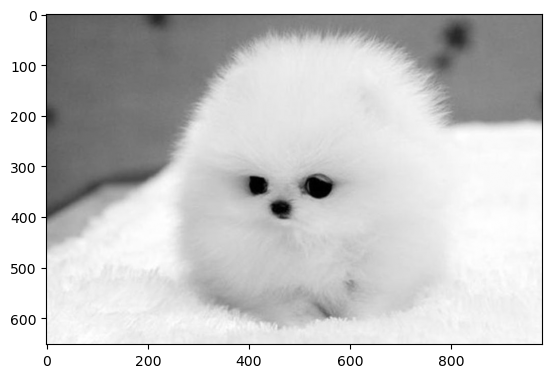

In [72]:
# Load the image
img = Image.open('puppy.jpg').convert('L')

# Convert image to a NumPy matrix (array)
# This results in a 2D array (Height, Width, Channels)
matrix = np.asarray(img)
plt.imshow(matrix,cmap='gray')

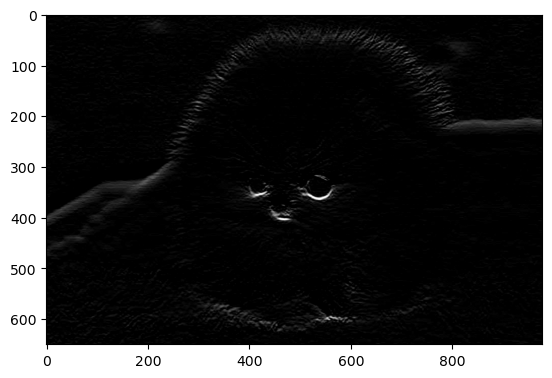

In [74]:
kernel = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])
convolvedImg = convolve(matrix, kernel)
convolvedImg = np.clip(convolvedImg, 0, 255)
convolvedImg = convolvedImg.astype('uint8')
plt.imshow(convolvedImg, cmap='gray')

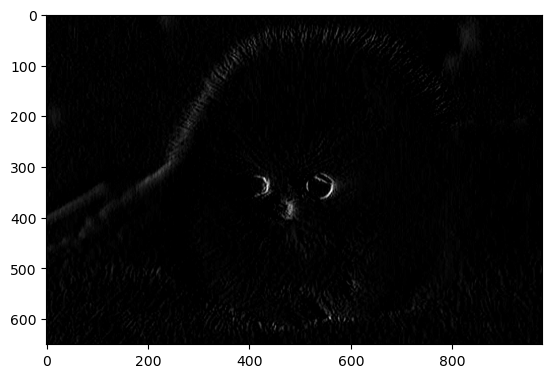

In [76]:
kernel = np.array([[-1, 0, 1],
                   [ -2,  0,  2],
                   [ -1,  0,  1]])
convolvedImg = convolve(matrix, kernel)
convolvedImg = np.clip(convolvedImg, 0, 255)
convolvedImg = convolvedImg.astype('uint8')
plt.imshow(convolvedImg, cmap='gray')

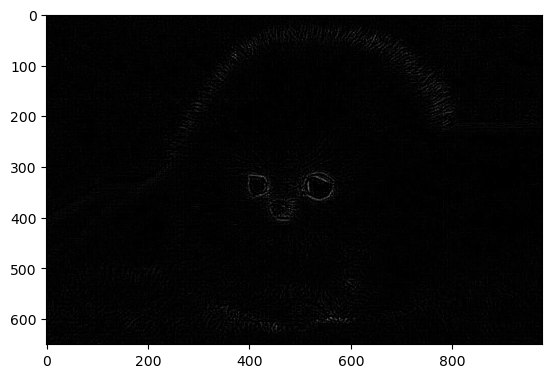

In [79]:
kernel = np.array([[0, -2, 0],
                   [ -2,  8,  -2],
                   [ 0,  -2, 0]])
convolvedImg = convolve(matrix, kernel)
convolvedImg = np.clip(convolvedImg, 0, 255)
convolvedImg = convolvedImg.astype('uint8')
plt.imshow(convolvedImg, cmap='gray')

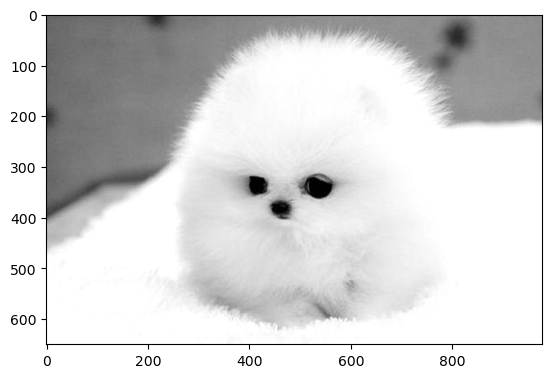

In [87]:
kernel = np.array([[0, 0, 0],
                   [0, 2, 0],
                    [0, 0, 0]]) -\
                (1/10)*np.ones((3,3))
convolvedImg = convolve(matrix, kernel)
convolvedImg = np.clip(convolvedImg, 0, 255)
convolvedImg = convolvedImg.astype('uint8')
plt.imshow(convolvedImg, cmap='gray')


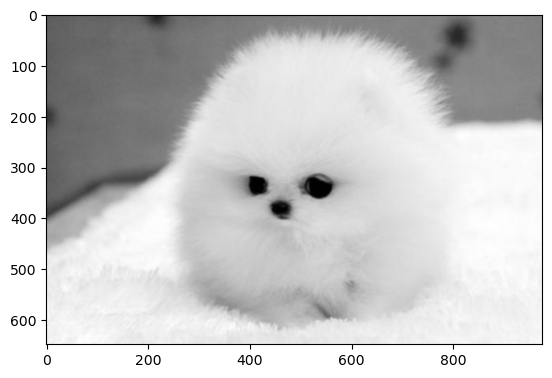

In [90]:
## gaussian blur
kernel = np.array([[1, 4, 6, 4, 1],
                   [4, 16, 24, 16, 4],
                   [6, 24, 36, 24, 6],
                   [4, 16, 24, 16, 4],
                   [1, 4, 6, 4, 1]]) / (256)
covolvedImg = convolve(matrix, kernel)
covolvedImg = np.clip(covolvedImg, 0, 255)
covolvedImg = covolvedImg.astype('uint8')
plt.imshow(covolvedImg, cmap='gray')